# **<span style="color:orange">Traitement de la base données de données de travail</span>**

In [58]:
from sklearn.impute import MissingIndicator, KNNImputer, SimpleImputer
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import missingno as msno

In [32]:
# Exportation de la base brut 
base = pd.read_csv(r'data/quality_of_life_brut.csv')
base.head()

,country,Purchasing Power Value,Purchasing Power Category,Safety Value,Safety Category,Health Care Value,Health Care Category,Climate Value,Climate Category,Cost of Living Value,Cost of Living Category,Property Price to Income Value,Property Price to Income Category,Traffic Commute Time Value,Traffic Commute Time Category,Pollution Value,Pollution Category,Quality of Life Value,Quality of Life Category
0,Afghanistan,32.15,'Very Low',25.33,'Low',24.24,'Low',0.00,NaN,21.08,'Very Low',7.8,'Low',56.17,'Very High',84.44,'Very High',0.0,NaN
1,Aland Islands,125.01,'Very High',71.81,'High',79.72,'High',0.00,NaN,53.44,'Low',5.33,'Low',19.05,'Very Low',18.05,'Very Low',0.0,NaN
2,Albania,42.82,'Low',55.52,'Moderate',48.21,'Moderate',86.43,'Very High',40.85,'Low',14.88,'High',36.74,'Moderate',77.25,'High',': 104.16','Low'
3,Alderney,0.00,NaN,83.79,'Very High',100.00,'Very High',0.00,NaN,0.00,NaN,0.0,NaN,5.00,'Very Low',1.72,'Very Low',0.0,NaN
4,Algeria,27.60,'Very Low',47.54,'Moderate',54.43,'Moderate',94.82,'Very High',25.31,'Very Low',21.7,'Very High',45.09,'High',63.87,'High',': 98.83','Very Low'


In [ ]:
# Remplacer les "O.O" par les NaN
base.replace('0.0', np.nan, inplace=True)
base

,country,Purchasing Power Value,Purchasing Power Category,Safety Value,Safety Category,Health Care Value,Health Care Category,Climate Value,Climate Category,Cost of Living Value,Cost of Living Category,Property Price to Income Value,Property Price to Income Category,Traffic Commute Time Value,Traffic Commute Time Category,Pollution Value,Pollution Category,Quality of Life Value,Quality of Life Category
0,Afghanistan,32.15,'Very Low',25.33,'Low',24.24,'Low',0.00,NaN,21.08,'Very Low',7.8,'Low',56.17,'Very High',84.44,'Very High',NaN,NaN
1,Aland Islands,125.01,'Very High',71.81,'High',79.72,'High',0.00,NaN,53.44,'Low',5.33,'Low',19.05,'Very Low',18.05,'Very Low',NaN,NaN
2,Albania,42.82,'Low',55.52,'Moderate',48.21,'Moderate',86.43,'Very High',40.85,'Low',14.88,'High',36.74,'Moderate',77.25,'High',': 104.16','Low'
3,Alderney,0.00,NaN,83.79,'Very High',100.00,'Very High',0.00,NaN,0.00,NaN,NaN,NaN,5.00,'Very Low',1.72,'Very Low',NaN,NaN
4,Algeria,27.60,'Very Low',47.54,'Moderate',54.43,'Moderate',94.82,'Very High',25.31,'Very Low',21.7,'Very High',45.09,'High',63.87,'High',': 98.83','Very Low'
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
231,Wallis And Futuna,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,NaN,NaN,0.00,NaN,0.00,NaN,NaN,NaN
232,Western Sahara,0.00,NaN,62.87,'High',0.00,NaN,0.00,NaN,0.00,NaN,12.75,'High',0.00,NaN,0.00,NaN,NaN,NaN
233,Yemen,20.74,'Very Low',34.07,'Low',25.31,'Low',0.00,NaN,48.66,'Low',15.98,'High',15.00,'Very Low',83.17,'Very High',NaN,NaN
234,Zambia,22.32,'Very Low',54.39,'Moderate',54.44,'Moderate',0.00,NaN,36.74,'Very Low',72.42,'Very High',38.86,'Moderate',80.90,'Very High',NaN,NaN


In [44]:
import numpy as np

base.replace(0.0, np.nan, inplace=True)
base

,country,Purchasing Power Value,Purchasing Power Category,Safety Value,Safety Category,Health Care Value,Health Care Category,Climate Value,Climate Category,Cost of Living Value,Cost of Living Category,Property Price to Income Value,Property Price to Income Category,Traffic Commute Time Value,Traffic Commute Time Category,Pollution Value,Pollution Category,Quality of Life Value,Quality of Life Category
0,Afghanistan,32.15,'Very Low',25.33,'Low',24.24,'Low',NaN,NaN,21.08,'Very Low',7.8,'Low',56.17,'Very High',84.44,'Very High',NaN,NaN
1,Aland Islands,125.01,'Very High',71.81,'High',79.72,'High',NaN,NaN,53.44,'Low',5.33,'Low',19.05,'Very Low',18.05,'Very Low',NaN,NaN
2,Albania,42.82,'Low',55.52,'Moderate',48.21,'Moderate',86.43,'Very High',40.85,'Low',14.88,'High',36.74,'Moderate',77.25,'High',': 104.16','Low'
3,Alderney,NaN,NaN,83.79,'Very High',100.00,'Very High',NaN,NaN,NaN,NaN,NaN,NaN,5.00,'Very Low',1.72,'Very Low',NaN,NaN
4,Algeria,27.60,'Very Low',47.54,'Moderate',54.43,'Moderate',94.82,'Very High',25.31,'Very Low',21.7,'Very High',45.09,'High',63.87,'High',': 98.83','Very Low'
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
231,Wallis And Futuna,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
232,Western Sahara,NaN,NaN,62.87,'High',NaN,NaN,NaN,NaN,NaN,NaN,12.75,'High',NaN,NaN,NaN,NaN,NaN,NaN
233,Yemen,20.74,'Very Low',34.07,'Low',25.31,'Low',NaN,NaN,48.66,'Low',15.98,'High',15.00,'Very Low',83.17,'Very High',NaN,NaN
234,Zambia,22.32,'Very Low',54.39,'Moderate',54.44,'Moderate',NaN,NaN,36.74,'Very Low',72.42,'Very High',38.86,'Moderate',80.90,'Very High',NaN,NaN


In [45]:
# Convertir les colonnes numériques en enlevant tous les caractères et en gardant uniquement les chiffres
numeric_columns = ['Purchasing Power Value', 'Safety Value', 'Health Care Value', 'Climate Value', 
                   'Cost of Living Value', 'Property Price to Income Value', 'Traffic Commute Time Value', 
                   'Pollution Value', 'Quality of Life Value']

for column in numeric_columns:
    base[column] = pd.to_numeric(base[column].astype(str).str.extract('(\d+\.?\d*)')[0], errors='coerce')

base

<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\d'
C:\Users\ABDOULAYE\AppData\Local\Temp\ipykernel_9396\3303821916.py:7: SyntaxWarning: invalid escape sequence '\d'
  base[column] = pd.to_numeric(base[column].astype(str).str.extract('(\d+\.?\d*)')[0], errors='coerce')


,country,Purchasing Power Value,Purchasing Power Category,Safety Value,Safety Category,Health Care Value,Health Care Category,Climate Value,Climate Category,Cost of Living Value,Cost of Living Category,Property Price to Income Value,Property Price to Income Category,Traffic Commute Time Value,Traffic Commute Time Category,Pollution Value,Pollution Category,Quality of Life Value,Quality of Life Category
0,Afghanistan,32.15,'Very Low',25.33,'Low',24.24,'Low',NaN,NaN,21.08,'Very Low',7.80,'Low',56.17,'Very High',84.44,'Very High',NaN,NaN
1,Aland Islands,125.01,'Very High',71.81,'High',79.72,'High',NaN,NaN,53.44,'Low',5.33,'Low',19.05,'Very Low',18.05,'Very Low',NaN,NaN
2,Albania,42.82,'Low',55.52,'Moderate',48.21,'Moderate',86.43,'Very High',40.85,'Low',14.88,'High',36.74,'Moderate',77.25,'High',104.16,'Low'
3,Alderney,NaN,NaN,83.79,'Very High',100.00,'Very High',NaN,NaN,NaN,NaN,NaN,NaN,5.00,'Very Low',1.72,'Very Low',NaN,NaN
4,Algeria,27.60,'Very Low',47.54,'Moderate',54.43,'Moderate',94.82,'Very High',25.31,'Very Low',21.70,'Very High',45.09,'High',63.87,'High',98.83,'Very Low'
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
231,Wallis And Futuna,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
232,Western Sahara,NaN,NaN,62.87,'High',NaN,NaN,NaN,NaN,NaN,NaN,12.75,'High',NaN,NaN,NaN,NaN,NaN,NaN
233,Yemen,20.74,'Very Low',34.07,'Low',25.31,'Low',NaN,NaN,48.66,'Low',15.98,'High',15.00,'Very Low',83.17,'Very High',NaN,NaN
234,Zambia,22.32,'Very Low',54.39,'Moderate',54.44,'Moderate',NaN,NaN,36.74,'Very Low',72.42,'Very High',38.86,'Moderate',80.90,'Very High',NaN,NaN


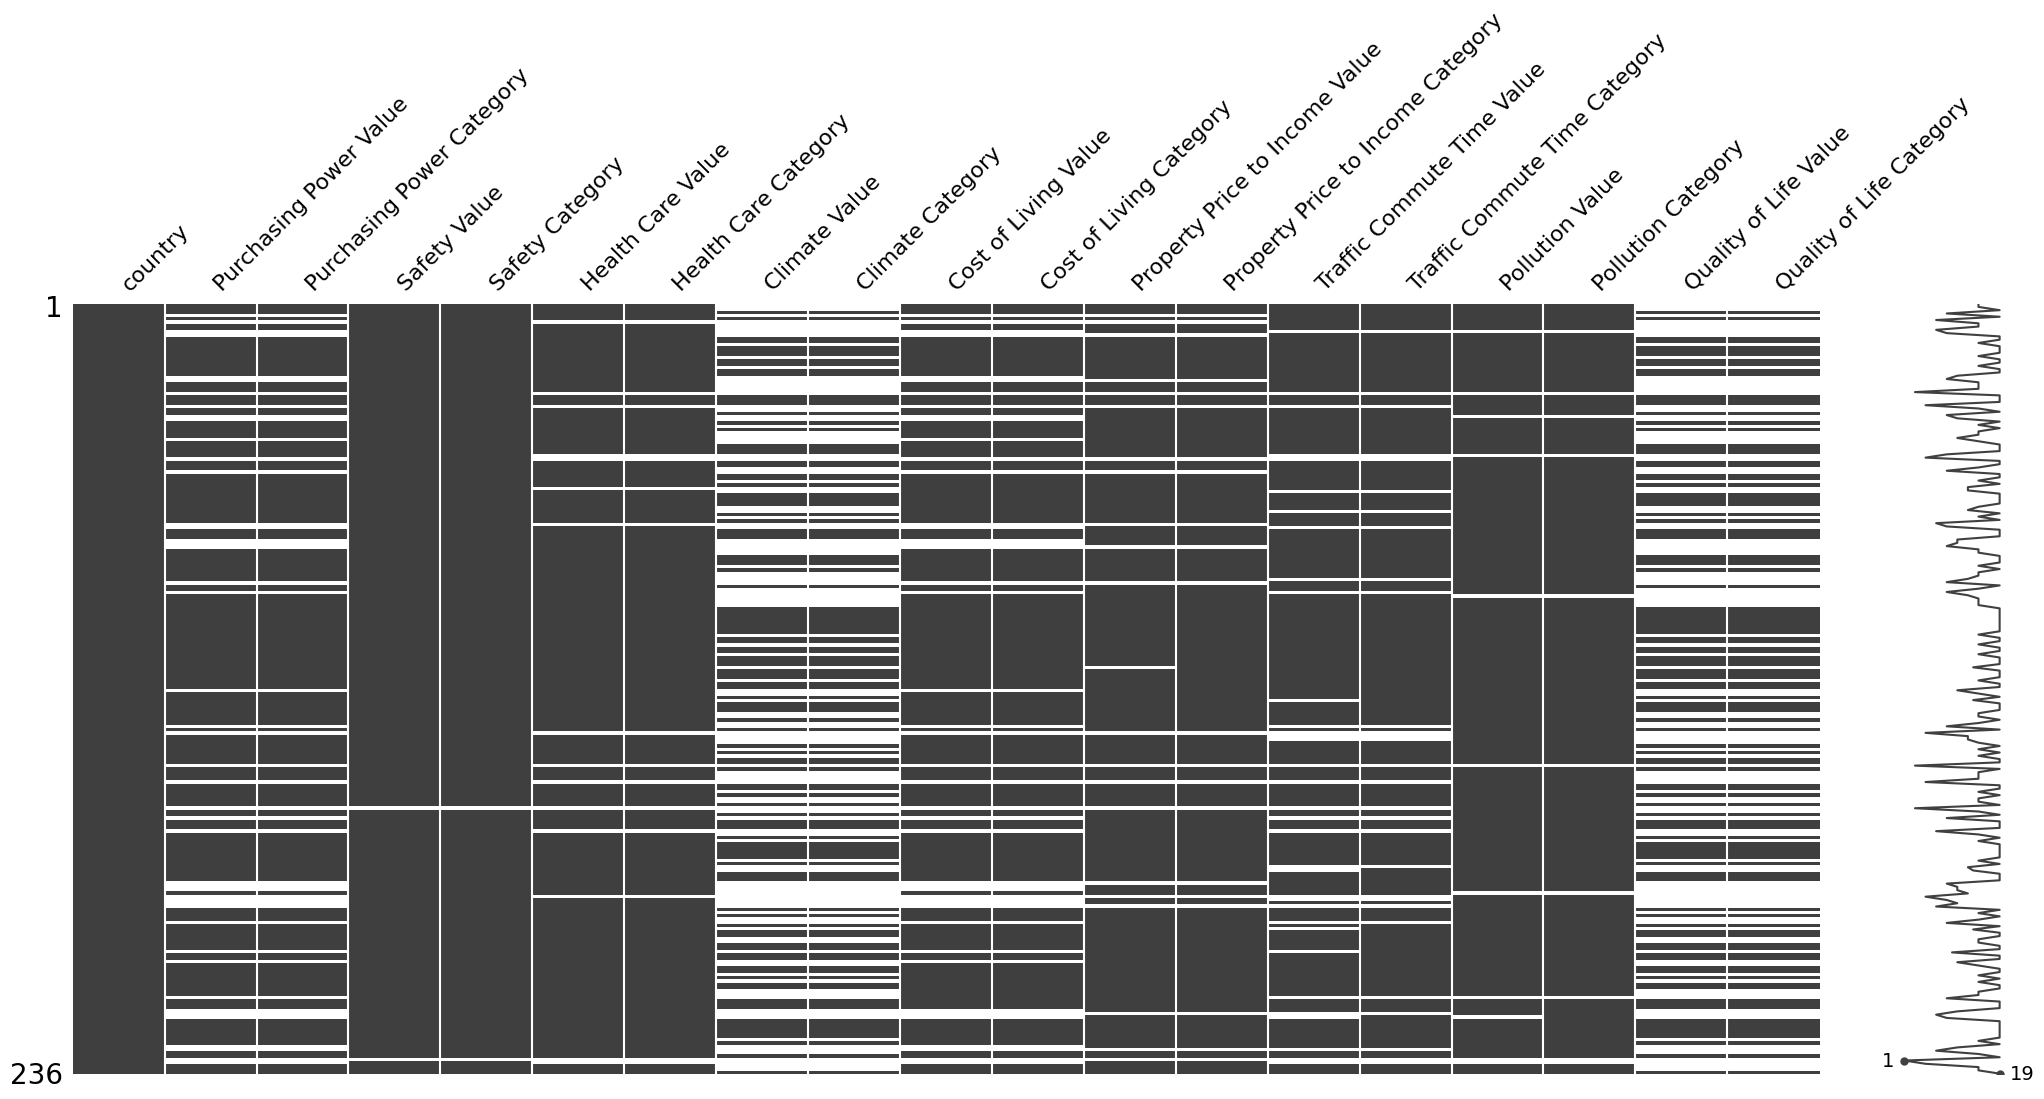

In [46]:
# Visualiser les valeurs manquantes avec missingno
msno.matrix(base)
plt.show()

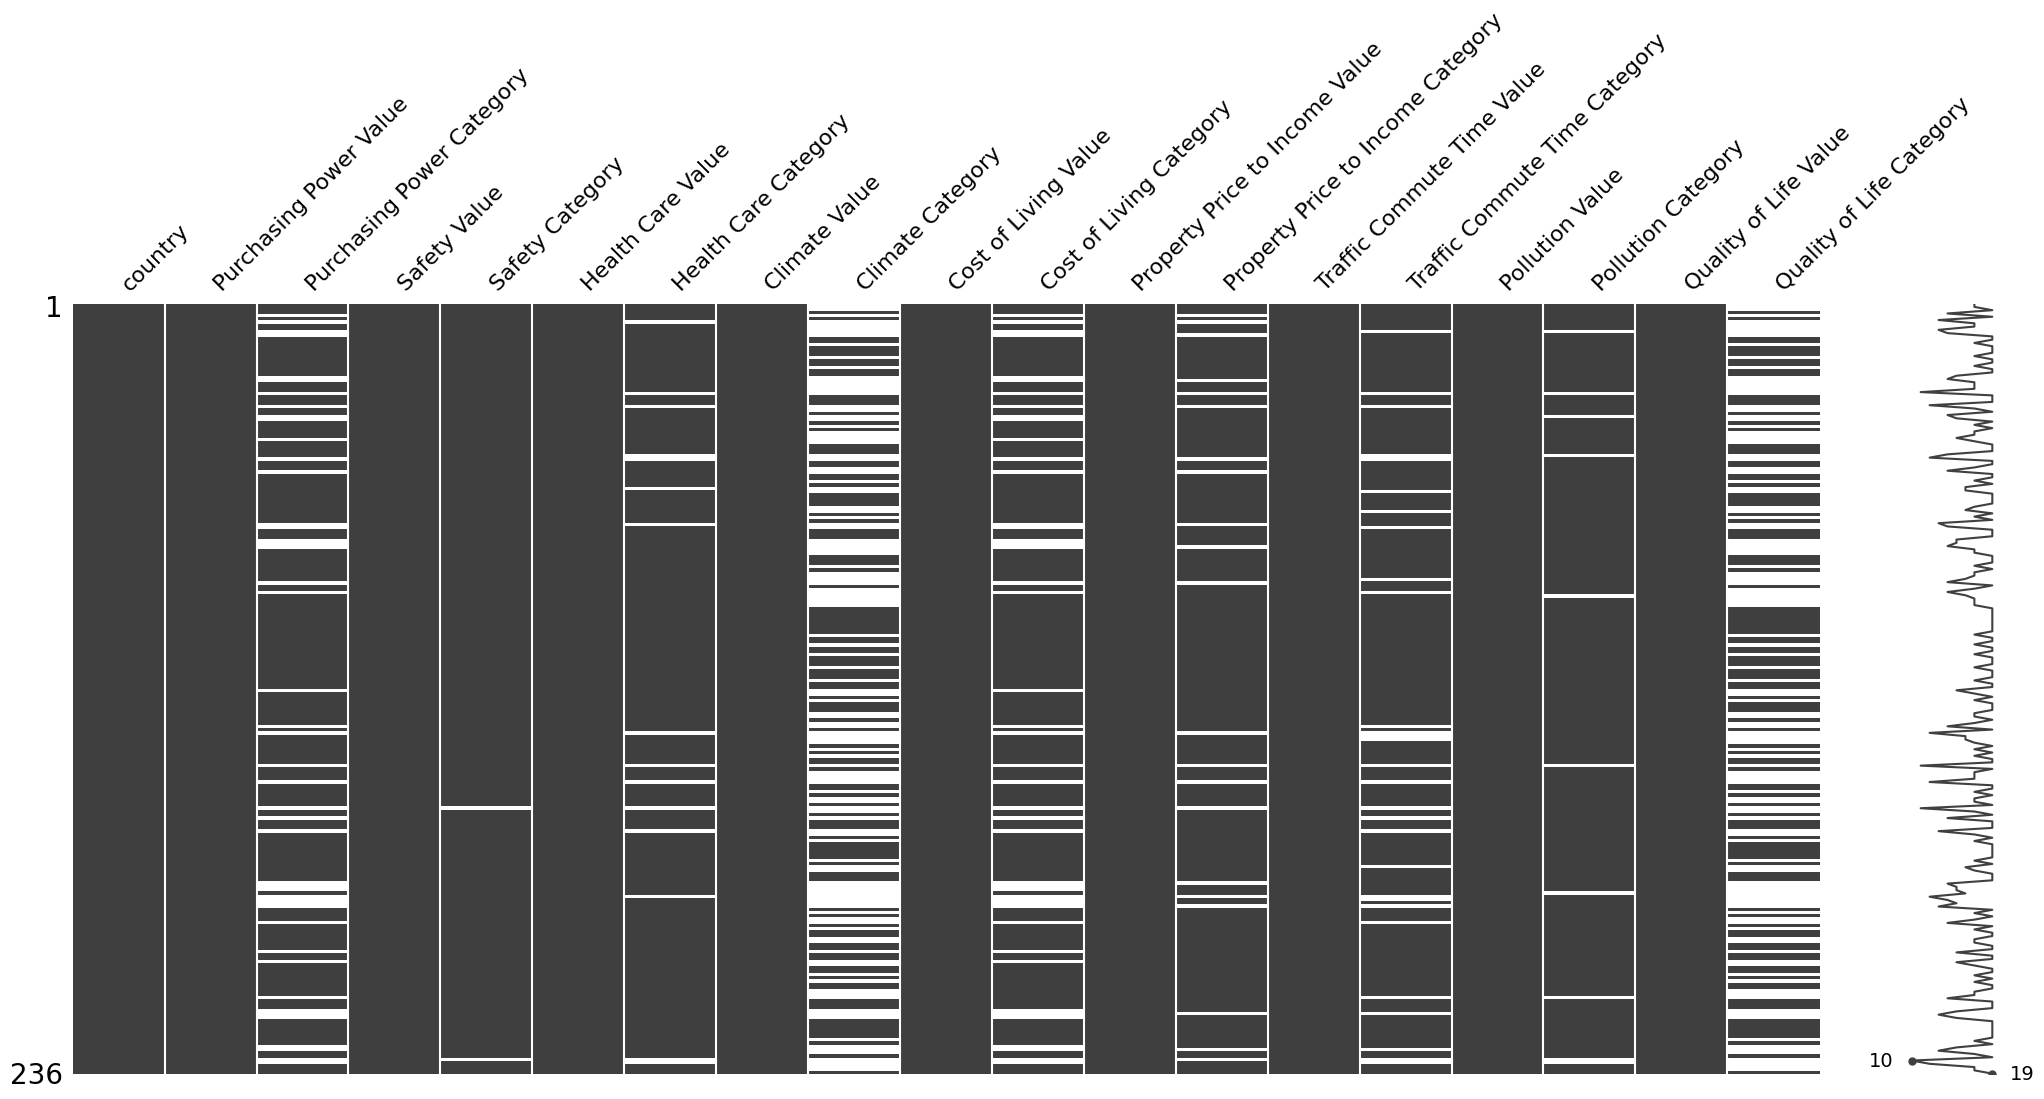

In [ ]:

# Imputation des données par le modèle KNN (Plus prôche voisin de 5), 
# remplace la valeur des NaN par la moyennes des 5 plus prôches voisins
imputer = KNNImputer(n_neighbors=5)

base[['Purchasing Power Value', 'Climate Value', 'Cost of Living Value', 'Property Price to Income Value', 'Traffic Commute Time Value', 'Pollution Value', 'Quality of Life Value','Health Care Value', 'Safety Value']] = imputer.fit_transform(base[['Purchasing Power Value', 'Climate Value', 'Cost of Living Value', 'Property Price to Income Value', 'Traffic Commute Time Value', 'Pollution Value', 'Quality of Life Value', 'Health Care Value', 'Safety Value']])

msno.matrix(base)
plt.show()

## Recodage des categories

In [48]:
# Liste des colonnes qualitatives
qualitative_columns = [col for col in base.columns if 'Category' in col]

# Supprimer les guillemets dans les colonnes qualitatives
for col in qualitative_columns:
    base[col] = base[col].str.replace("'", "")

base

,country,Purchasing Power Value,Purchasing Power Category,Safety Value,Safety Category,Health Care Value,Health Care Category,Climate Value,Climate Category,Cost of Living Value,Cost of Living Category,Property Price to Income Value,Property Price to Income Category,Traffic Commute Time Value,Traffic Commute Time Category,Pollution Value,Pollution Category,Quality of Life Value,Quality of Life Category
0,Afghanistan,32.150000,Very Low,25.33000,Low,24.24000,Low,81.66200,NaN,21.080000,Very Low,7.800000,Low,56.170000,Very High,84.4400,Very High,76.026000,NaN
1,Aland Islands,125.010000,Very High,71.81000,High,79.72000,High,74.93200,NaN,53.440000,Low,5.330000,Low,19.050000,Very Low,18.0500,Very Low,202.022000,NaN
2,Albania,42.820000,Low,55.52000,Moderate,48.21000,Moderate,86.43000,Very High,40.850000,Low,14.880000,High,36.740000,Moderate,77.2500,High,104.160000,Low
3,Alderney,119.366000,NaN,83.79000,Very High,100.00000,Very High,74.08800,NaN,54.876000,NaN,7.610000,NaN,5.000000,Very Low,1.7200,Very Low,200.146000,NaN
4,Algeria,27.600000,Very Low,47.54000,Moderate,54.43000,Moderate,94.82000,Very High,25.310000,Very Low,21.700000,Very High,45.090000,High,63.8700,High,98.830000,Very Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
231,Wallis And Futuna,69.027895,NaN,55.74688,NaN,58.44638,NaN,77.89693,NaN,46.367592,NaN,24.295561,NaN,33.288812,NaN,56.9192,NaN,131.387368,NaN
232,Western Sahara,54.486000,NaN,62.87000,High,47.01000,NaN,74.08400,NaN,34.868000,NaN,12.750000,High,28.864000,NaN,71.5440,NaN,133.720000,NaN
233,Yemen,20.740000,Very Low,34.07000,Low,25.31000,Low,68.94800,NaN,48.660000,Low,15.980000,High,15.000000,Very Low,83.1700,Very High,65.738000,NaN
234,Zambia,22.320000,Very Low,54.39000,Moderate,54.44000,Moderate,75.00600,NaN,36.740000,Very Low,72.420000,Very High,38.860000,Moderate,80.9000,Very High,61.882000,NaN


In [ ]:
# Surpression de la colonne 'country'
base.drop(columns=['country'], inplace=True)
base

,Purchasing Power Value,Purchasing Power Category,Safety Value,Safety Category,Health Care Value,Health Care Category,Climate Value,Climate Category,Cost of Living Value,Cost of Living Category,Property Price to Income Value,Property Price to Income Category,Traffic Commute Time Value,Traffic Commute Time Category,Pollution Value,Pollution Category,Quality of Life Value,Quality of Life Category
0,32.150000,Very Low,25.33000,Low,24.24000,Low,81.66200,NaN,21.080000,Very Low,7.800000,Low,56.170000,Very High,84.4400,Very High,76.026000,NaN
1,125.010000,Very High,71.81000,High,79.72000,High,74.93200,NaN,53.440000,Low,5.330000,Low,19.050000,Very Low,18.0500,Very Low,202.022000,NaN
2,42.820000,Low,55.52000,Moderate,48.21000,Moderate,86.43000,Very High,40.850000,Low,14.880000,High,36.740000,Moderate,77.2500,High,104.160000,Low
3,119.366000,NaN,83.79000,Very High,100.00000,Very High,74.08800,NaN,54.876000,NaN,7.610000,NaN,5.000000,Very Low,1.7200,Very Low,200.146000,NaN
4,27.600000,Very Low,47.54000,Moderate,54.43000,Moderate,94.82000,Very High,25.310000,Very Low,21.700000,Very High,45.090000,High,63.8700,High,98.830000,Very Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
231,69.027895,NaN,55.74688,NaN,58.44638,NaN,77.89693,NaN,46.367592,NaN,24.295561,NaN,33.288812,NaN,56.9192,NaN,131.387368,NaN
232,54.486000,NaN,62.87000,High,47.01000,NaN,74.08400,NaN,34.868000,NaN,12.750000,High,28.864000,NaN,71.5440,NaN,133.720000,NaN
233,20.740000,Very Low,34.07000,Low,25.31000,Low,68.94800,NaN,48.660000,Low,15.980000,High,15.000000,Very Low,83.1700,Very High,65.738000,NaN
234,22.320000,Very Low,54.39000,Moderate,54.44000,Moderate,75.00600,NaN,36.740000,Very Low,72.420000,Very High,38.860000,Moderate,80.9000,Very High,61.882000,NaN


In [59]:
print(quantiles)

                             min     max
Quality of Life Category                
Very Low                    0.00   99.98
Low                       101.33  119.96
Moderate                  120.52  144.49
High                      147.33  159.55
Very High                 160.18  224.31


In [50]:
import pandas as pd
import numpy as np

# Fonction pour déterminer la catégorie en fonction d'une valeur quantitative
def assign_category(value, thresholds):
    if pd.isna(value):
        return np.nan
    elif value <= thresholds[0]:
        return "Very Low"
    elif value <= thresholds[1]:
        return "Low"
    elif value <= thresholds[2]:
        return "Moderate"
    elif value <= thresholds[3]:
        return "High"
    elif value <= thresholds[4]:
        return "Very High"
    else:
        return "Very High"  # Ajout pour gérer les valeurs > dernier seuil

# Supposons que les colonnes sont alternées : quant1, cat1, quant2, cat2, etc.
all_columns = base.columns.tolist()
quantitative_cols = all_columns[::2]  # indices pairs
categorical_cols = all_columns[1::2]  # indices impairs

# Dictionnaire pour stocker les seuils pour chaque paire
thresholds_dict = {}

# Étape 1 : Calculer les seuils pour chaque paire quant/cat (basé sur les données non manquantes)
for quant_col, cat_col in zip(quantitative_cols, categorical_cols):
    # Sélectionner les lignes où la catégorie n'est pas manquante
    valid_data = base[[quant_col, cat_col]].dropna()
    
    # Calculer les quantiles (ou seuils) basés sur les catégories existantes
    quantiles = valid_data.groupby(cat_col)[quant_col].agg(['min', 'max']).sort_values('min')
    
    # Définir les seuils avec arrondi à l'entier supérieur
    thresholds = [
        np.ceil(quantiles.loc["Very Low", "max"]) if "Very Low" in quantiles.index else float('-inf'),
        np.ceil(quantiles.loc["Low", "max"]) if "Low" in quantiles.index else float('-inf'),
        np.ceil(quantiles.loc["Moderate", "max"]) if "Moderate" in quantiles.index else float('-inf'),
        np.ceil(quantiles.loc["High", "max"]) if "High" in quantiles.index else float('-inf'),
        np.ceil(quantiles.loc["Very High", "max"]) if "Very High" in quantiles.index else float('-inf')
    ]
    thresholds_dict[quant_col] = thresholds

# Étape 2 : Imputer les valeurs manquantes
for quant_col, cat_col in zip(quantitative_cols, categorical_cols):
    # Récupérer les seuils pour cette paire
    thresholds = thresholds_dict[quant_col]
    
    # Appliquer la fonction pour remplir les NA
    mask = base[cat_col].isna()
    base.loc[mask, cat_col] = base.loc[mask, quant_col].apply(
        lambda x: assign_category(x, thresholds)
    )

# Vérification
for quant_col, cat_col in zip(quantitative_cols, categorical_cols):
    print(f"\nRésultat pour {quant_col} et {cat_col}:")
    print(base[[quant_col, cat_col]].head())
    print(f"Nombre de valeurs manquantes restantes en {cat_col}: {base[cat_col].isna().sum()}")


Résultat pour Purchasing Power Value et Purchasing Power Category:
   Purchasing Power Value Purchasing Power Category
0                  32.150                  Very Low
1                 125.010                 Very High
2                  42.820                       Low
3                 119.366                 Very High
4                  27.600                  Very Low
Nombre de valeurs manquantes restantes en Purchasing Power Category: 0

Résultat pour Safety Value et Safety Category:
   Safety Value Safety Category
0         25.33             Low
1         71.81            High
2         55.52        Moderate
3         83.79       Very High
4         47.54        Moderate
Nombre de valeurs manquantes restantes en Safety Category: 0

Résultat pour Health Care Value et Health Care Category:
   Health Care Value Health Care Category
0              24.24                  Low
1              79.72                 High
2              48.21             Moderate
3             100.00  

In [51]:
base1 = pd.read_csv('data/quality_of_life_brut.csv')
base1

,country,Purchasing Power Value,Purchasing Power Category,Safety Value,Safety Category,Health Care Value,Health Care Category,Climate Value,Climate Category,Cost of Living Value,Cost of Living Category,Property Price to Income Value,Property Price to Income Category,Traffic Commute Time Value,Traffic Commute Time Category,Pollution Value,Pollution Category,Quality of Life Value,Quality of Life Category
0,Afghanistan,32.15,'Very Low',25.33,'Low',24.24,'Low',0.00,NaN,21.08,'Very Low',7.8,'Low',56.17,'Very High',84.44,'Very High',0.0,NaN
1,Aland Islands,125.01,'Very High',71.81,'High',79.72,'High',0.00,NaN,53.44,'Low',5.33,'Low',19.05,'Very Low',18.05,'Very Low',0.0,NaN
2,Albania,42.82,'Low',55.52,'Moderate',48.21,'Moderate',86.43,'Very High',40.85,'Low',14.88,'High',36.74,'Moderate',77.25,'High',': 104.16','Low'
3,Alderney,0.00,NaN,83.79,'Very High',100.00,'Very High',0.00,NaN,0.00,NaN,0.0,NaN,5.00,'Very Low',1.72,'Very Low',0.0,NaN
4,Algeria,27.60,'Very Low',47.54,'Moderate',54.43,'Moderate',94.82,'Very High',25.31,'Very Low',21.7,'Very High',45.09,'High',63.87,'High',': 98.83','Very Low'
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
231,Wallis And Futuna,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.0,NaN,0.00,NaN,0.00,NaN,0.0,NaN
232,Western Sahara,0.00,NaN,62.87,'High',0.00,NaN,0.00,NaN,0.00,NaN,12.75,'High',0.00,NaN,0.00,NaN,0.0,NaN
233,Yemen,20.74,'Very Low',34.07,'Low',25.31,'Low',0.00,NaN,48.66,'Low',15.98,'High',15.00,'Very Low',83.17,'Very High',0.0,NaN
234,Zambia,22.32,'Very Low',54.39,'Moderate',54.44,'Moderate',0.00,NaN,36.74,'Very Low',72.42,'Very High',38.86,'Moderate',80.90,'Very High',0.0,NaN


In [52]:
base['country'] = base1['country']

In [53]:
# Move the 'country' column to the first position
cols = ['country'] + [col for col in base.columns if col != 'country']
base = base[cols]
base

,country,Purchasing Power Value,Purchasing Power Category,Safety Value,Safety Category,Health Care Value,Health Care Category,Climate Value,Climate Category,Cost of Living Value,Cost of Living Category,Property Price to Income Value,Property Price to Income Category,Traffic Commute Time Value,Traffic Commute Time Category,Pollution Value,Pollution Category,Quality of Life Value,Quality of Life Category
0,Afghanistan,32.150000,Very Low,25.33000,Low,24.24000,Low,81.66200,Very High,21.080000,Very Low,7.800000,Low,56.170000,Very High,84.4400,Very High,76.026000,Very Low
1,Aland Islands,125.010000,Very High,71.81000,High,79.72000,High,74.93200,High,53.440000,Low,5.330000,Low,19.050000,Very Low,18.0500,Very Low,202.022000,Very High
2,Albania,42.820000,Low,55.52000,Moderate,48.21000,Moderate,86.43000,Very High,40.850000,Low,14.880000,High,36.740000,Moderate,77.2500,High,104.160000,Low
3,Alderney,119.366000,Very High,83.79000,Very High,100.00000,Very High,74.08800,High,54.876000,Low,7.610000,Very Low,5.000000,Very Low,1.7200,Very Low,200.146000,Very High
4,Algeria,27.600000,Very Low,47.54000,Moderate,54.43000,Moderate,94.82000,Very High,25.310000,Very Low,21.700000,Very High,45.090000,High,63.8700,High,98.830000,Very Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
231,Wallis And Futuna,69.027895,Moderate,55.74688,Moderate,58.44638,Moderate,77.89693,High,46.367592,Low,24.295561,Very High,33.288812,Very Low,56.9192,Moderate,131.387368,Moderate
232,Western Sahara,54.486000,Low,62.87000,High,47.01000,Moderate,74.08400,High,34.868000,Very Low,12.750000,High,28.864000,Very Low,71.5440,High,133.720000,Moderate
233,Yemen,20.740000,Very Low,34.07000,Low,25.31000,Low,68.94800,High,48.660000,Low,15.980000,High,15.000000,Very Low,83.1700,Very High,65.738000,Very Low
234,Zambia,22.320000,Very Low,54.39000,Moderate,54.44000,Moderate,75.00600,High,36.740000,Very Low,72.420000,Very High,38.860000,Moderate,80.9000,Very High,61.882000,Very Low


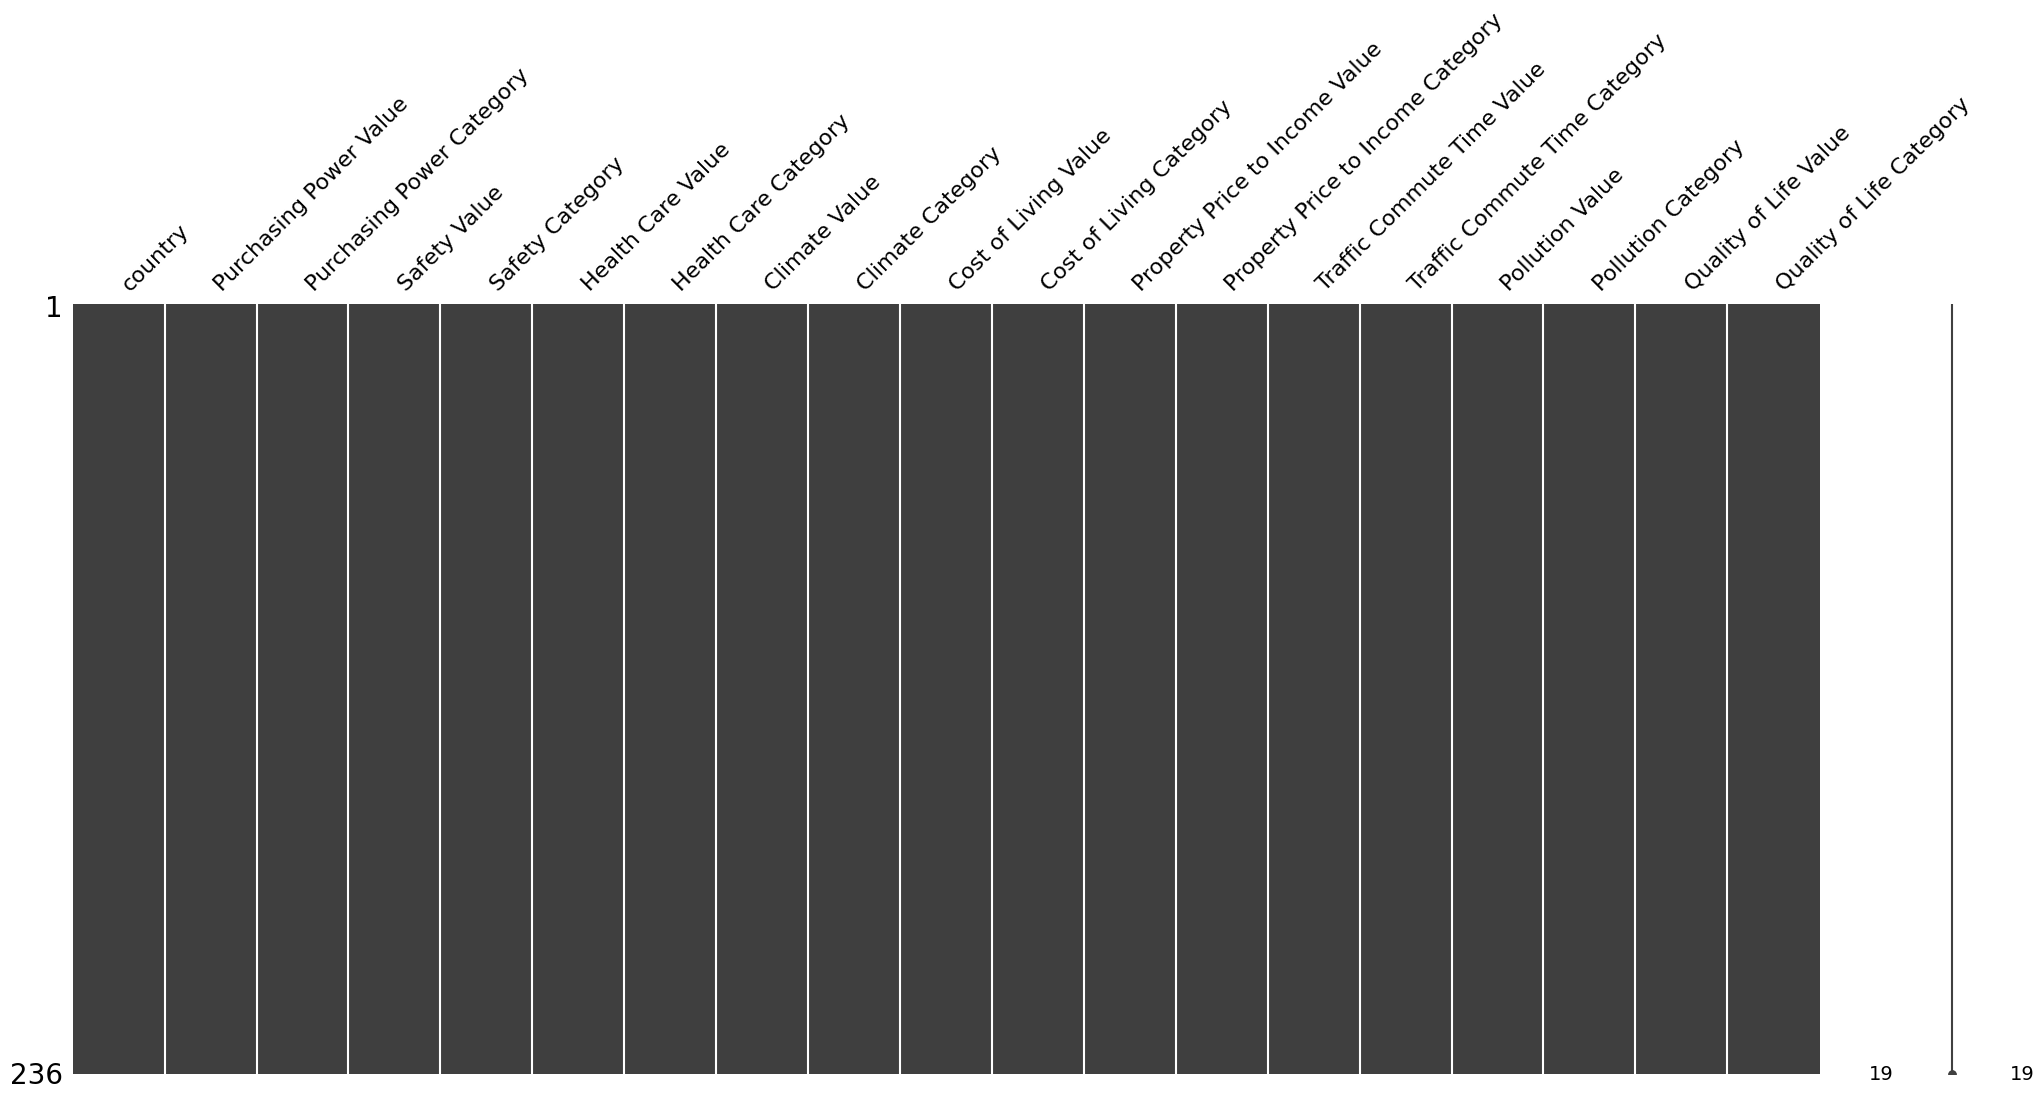

In [54]:
msno.matrix(base)
plt.show()

In [55]:
# Convertir les valeurs des variables quantitatives à deux chiffres après la virgule
quantitative_cols = ['Purchasing Power Value', 'Safety Value', 'Health Care Value', 'Climate Value', 
                     'Cost of Living Value', 'Property Price to Income Value', 'Traffic Commute Time Value', 
                     'Pollution Value', 'Quality of Life Value']

base[quantitative_cols] = base[quantitative_cols].round(2)
base

,country,Purchasing Power Value,Purchasing Power Category,Safety Value,Safety Category,Health Care Value,Health Care Category,Climate Value,Climate Category,Cost of Living Value,Cost of Living Category,Property Price to Income Value,Property Price to Income Category,Traffic Commute Time Value,Traffic Commute Time Category,Pollution Value,Pollution Category,Quality of Life Value,Quality of Life Category
0,Afghanistan,32.15,Very Low,25.33,Low,24.24,Low,81.66,Very High,21.08,Very Low,7.80,Low,56.17,Very High,84.44,Very High,76.03,Very Low
1,Aland Islands,125.01,Very High,71.81,High,79.72,High,74.93,High,53.44,Low,5.33,Low,19.05,Very Low,18.05,Very Low,202.02,Very High
2,Albania,42.82,Low,55.52,Moderate,48.21,Moderate,86.43,Very High,40.85,Low,14.88,High,36.74,Moderate,77.25,High,104.16,Low
3,Alderney,119.37,Very High,83.79,Very High,100.00,Very High,74.09,High,54.88,Low,7.61,Very Low,5.00,Very Low,1.72,Very Low,200.15,Very High
4,Algeria,27.60,Very Low,47.54,Moderate,54.43,Moderate,94.82,Very High,25.31,Very Low,21.70,Very High,45.09,High,63.87,High,98.83,Very Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
231,Wallis And Futuna,69.03,Moderate,55.75,Moderate,58.45,Moderate,77.90,High,46.37,Low,24.30,Very High,33.29,Very Low,56.92,Moderate,131.39,Moderate
232,Western Sahara,54.49,Low,62.87,High,47.01,Moderate,74.08,High,34.87,Very Low,12.75,High,28.86,Very Low,71.54,High,133.72,Moderate
233,Yemen,20.74,Very Low,34.07,Low,25.31,Low,68.95,High,48.66,Low,15.98,High,15.00,Very Low,83.17,Very High,65.74,Very Low
234,Zambia,22.32,Very Low,54.39,Moderate,54.44,Moderate,75.01,High,36.74,Very Low,72.42,Very High,38.86,Moderate,80.90,Very High,61.88,Very Low


In [56]:
base.to_csv('data/quality_of_life_cleaned.csv', index=False)

# **<span style="color:green">Traitement de la base données de données de contient </span>**

In [1]:
import pandas as pd

In [44]:
# Exportation de la base brut 
base_world = pd.read_csv(r'data/world_population.csv')
base_clean = pd.read_csv(r'data/quality_of_life_cleaned.csv')

base_world.head()

,Rank,CCA3,Country/Territory,Capital,Continent,2022 Population,2020 Population,2015 Population,2010 Population,2000 Population,1990 Population,1980 Population,1970 Population,Area (km²),Density (per km²),Growth Rate,World Population Percentage
0,36,AFG,Afghanistan,Kabul,Asia,41128771,38972230,33753499,28189672,19542982,10694796,12486631,10752971,652230,63.0587,1.0257,0.52
1,138,ALB,Albania,Tirana,Europe,2842321,2866849,2882481,2913399,3182021,3295066,2941651,2324731,28748,98.8702,0.9957,0.04
2,34,DZA,Algeria,Algiers,Africa,44903225,43451666,39543154,35856344,30774621,25518074,18739378,13795915,2381741,18.8531,1.0164,0.56
3,213,ASM,American Samoa,Pago Pago,Oceania,44273,46189,51368,54849,58230,47818,32886,27075,199,222.4774,0.9831,0.00
4,203,AND,Andorra,Andorra la Vella,Europe,79824,77700,71746,71519,66097,53569,35611,19860,468,170.5641,1.0100,0.00


In [34]:
base_world.shape

(234, 17)

In [45]:
# Surpression des colonnes 
list_drop = ["Rank",	"CCA3"	,"Capital",	"2022 Population",	"2020 Population",	"2015 Population"	,"2010 Population",	"2000 Population",	"1990 Population",	"1980 Population",	"1970 Population",	"Area (km²)",	"Density (per km²)",	"Growth Rate",	"World Population Percentage"]

base_continent = base_world.drop(columns= list_drop)
base_continent

,Country/Territory,Continent
0,Afghanistan,Asia
1,Albania,Europe
2,Algeria,Africa
3,American Samoa,Oceania
4,Andorra,Europe
...,...,...
229,Wallis and Futuna,Oceania
230,Western Sahara,Africa
231,Yemen,Asia
232,Zambia,Africa


In [ ]:
# Renomage de la colonne 'Country/Territory' en 'Country'
base_continent.rename(columns={'Country/Territory': 'country'}, inplace=True)

base_continent

,country,Continent
0,Afghanistan,Asia
1,Albania,Europe
2,Algeria,Africa
3,American Samoa,Oceania
4,Andorra,Europe
...,...,...
229,Wallis and Futuna,Oceania
230,Western Sahara,Africa
231,Yemen,Asia
232,Zambia,Africa


In [ ]:
# Sauvegarde des données
base_continent.to_csv("data/world_continent_country.csv")

## Fucion des bases de données

In [ ]:
# La fusion à droite 
base_merge  = pd.merge(base_clean, base_continent, on='country')
base_merge

,country,Purchasing Power Value,Purchasing Power Category,Safety Value,Safety Category,Health Care Value,Health Care Category,Climate Value,Climate Category,Cost of Living Value,Cost of Living Category,Property Price to Income Value,Property Price to Income Category,Traffic Commute Time Value,Traffic Commute Time Category,Pollution Value,Pollution Category,Quality of Life Value,Quality of Life Category,Continent
0,Afghanistan,32.15,Very Low,25.33,Low,24.24,Low,81.66,Very High,21.08,Very Low,7.80,Low,56.17,Very High,84.44,Very High,76.03,Very Low,Asia
1,Albania,42.82,Low,55.52,Moderate,48.21,Moderate,86.43,Very High,40.85,Low,14.88,High,36.74,Moderate,77.25,High,104.16,Low,Europe
2,Algeria,27.60,Very Low,47.54,Moderate,54.43,Moderate,94.82,Very High,25.31,Very Low,21.70,Very High,45.09,High,63.87,High,98.83,Very Low,Africa
3,American Samoa,57.08,Low,54.41,Moderate,56.67,Moderate,77.57,High,51.07,Low,34.92,Very High,100.00,Very High,78.45,High,69.54,Very Low,Oceania
4,Andorra,121.14,Very High,84.71,Very High,75.56,High,74.93,High,48.09,Low,9.03,Moderate,13.33,Very Low,22.98,Low,202.02,Very High,Europe
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211,Vietnam,44.49,Low,59.00,Moderate,61.32,High,71.24,High,26.85,Very Low,24.77,Very High,29.62,Low,84.19,Very High,97.18,Very Low,Asia
212,Western Sahara,54.49,Low,62.87,High,47.01,Moderate,74.08,High,34.87,Very Low,12.75,High,28.86,Very Low,71.54,High,133.72,Moderate,Africa
213,Yemen,20.74,Very Low,34.07,Low,25.31,Low,68.95,High,48.66,Low,15.98,High,15.00,Very Low,83.17,Very High,65.74,Very Low,Asia
214,Zambia,22.32,Very Low,54.39,Moderate,54.44,Moderate,75.01,High,36.74,Very Low,72.42,Very High,38.86,Moderate,80.90,Very High,61.88,Very Low,Africa


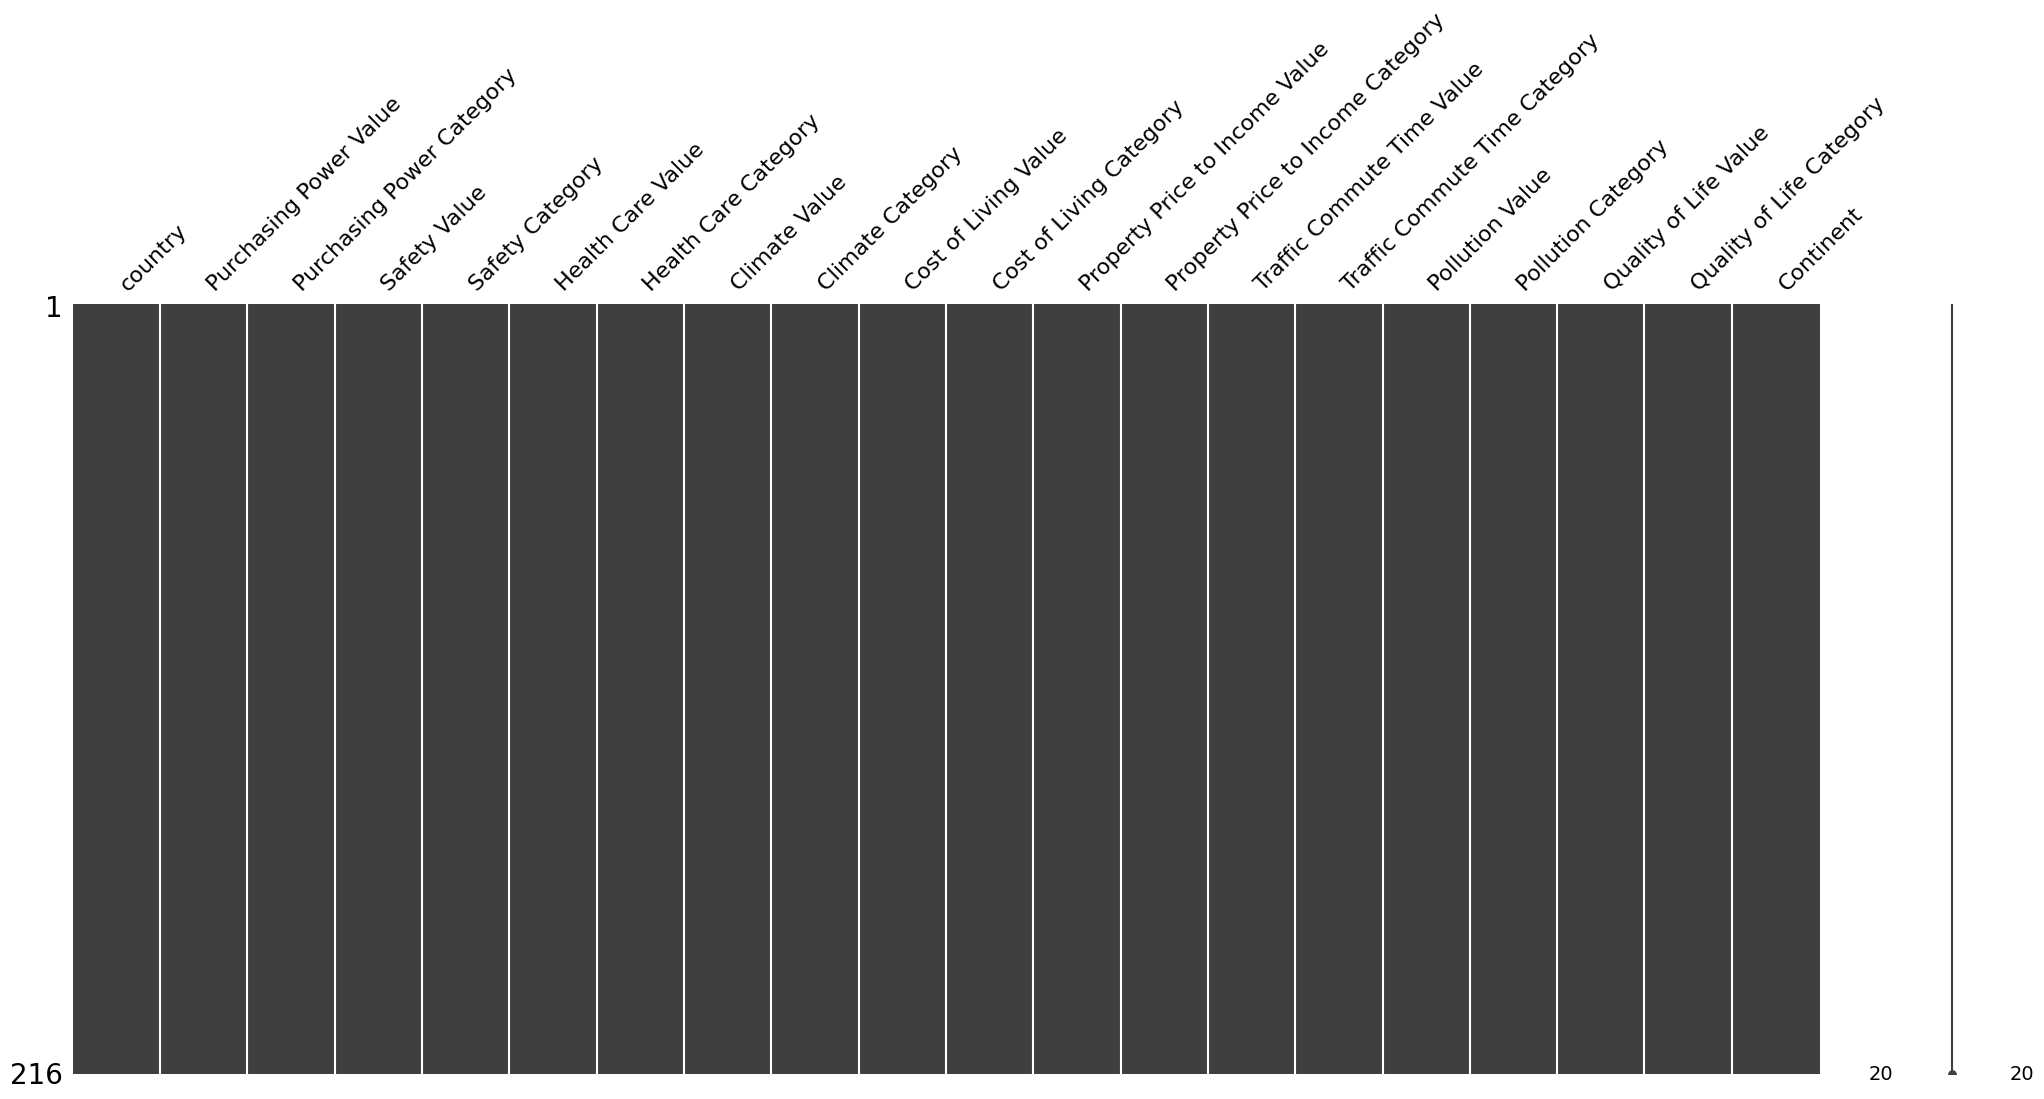

In [61]:
msno.matrix(base_merge)
plt.show()

In [ ]:
base_merge.to_csv("data/quality_of_life_cleaned.csv")

# **<span style="color:yellow">Création des variables normalisées </span>**

In [55]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

In [56]:

# Charger les données
base_clean_nor = pd.read_csv('data/quality_of_life_cleaned.csv')
base_clean_nor.head()

,Unnamed: 0,country,Purchasing Power Value,Purchasing Power Category,Safety Value,Safety Category,Health Care Value,Health Care Category,Climate Value,Climate Category,...,Cost of Living Category,Property Price to Income Value,Property Price to Income Category,Traffic Commute Time Value,Traffic Commute Time Category,Pollution Value,Pollution Category,Quality of Life Value,Quality of Life Category,Continent
0,0,Afghanistan,32.15,Very Low,25.33,Low,24.24,Low,81.66,Very High,...,Very Low,7.80,Low,56.17,Very High,84.44,Very High,76.03,Very Low,Asia
1,1,Albania,42.82,Low,55.52,Moderate,48.21,Moderate,86.43,Very High,...,Low,14.88,High,36.74,Moderate,77.25,High,104.16,Low,Europe
2,2,Algeria,27.60,Very Low,47.54,Moderate,54.43,Moderate,94.82,Very High,...,Very Low,21.70,Very High,45.09,High,63.87,High,98.83,Very Low,Africa
3,3,American Samoa,57.08,Low,54.41,Moderate,56.67,Moderate,77.57,High,...,Low,34.92,Very High,100.00,Very High,78.45,High,69.54,Very Low,Oceania
4,4,Andorra,121.14,Very High,84.71,Very High,75.56,High,74.93,High,...,Low,9.03,Moderate,13.33,Very Low,22.98,Low,202.02,Very High,Europe


In [57]:
base_clean_nor.drop(columns=['Unnamed: 0'], inplace=True)
base_clean_nor

,country,Purchasing Power Value,Purchasing Power Category,Safety Value,Safety Category,Health Care Value,Health Care Category,Climate Value,Climate Category,Cost of Living Value,Cost of Living Category,Property Price to Income Value,Property Price to Income Category,Traffic Commute Time Value,Traffic Commute Time Category,Pollution Value,Pollution Category,Quality of Life Value,Quality of Life Category,Continent
0,Afghanistan,32.15,Very Low,25.33,Low,24.24,Low,81.66,Very High,21.08,Very Low,7.80,Low,56.17,Very High,84.44,Very High,76.03,Very Low,Asia
1,Albania,42.82,Low,55.52,Moderate,48.21,Moderate,86.43,Very High,40.85,Low,14.88,High,36.74,Moderate,77.25,High,104.16,Low,Europe
2,Algeria,27.60,Very Low,47.54,Moderate,54.43,Moderate,94.82,Very High,25.31,Very Low,21.70,Very High,45.09,High,63.87,High,98.83,Very Low,Africa
3,American Samoa,57.08,Low,54.41,Moderate,56.67,Moderate,77.57,High,51.07,Low,34.92,Very High,100.00,Very High,78.45,High,69.54,Very Low,Oceania
4,Andorra,121.14,Very High,84.71,Very High,75.56,High,74.93,High,48.09,Low,9.03,Moderate,13.33,Very Low,22.98,Low,202.02,Very High,Europe
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211,Vietnam,44.49,Low,59.00,Moderate,61.32,High,71.24,High,26.85,Very Low,24.77,Very High,29.62,Low,84.19,Very High,97.18,Very Low,Asia
212,Western Sahara,54.49,Low,62.87,High,47.01,Moderate,74.08,High,34.87,Very Low,12.75,High,28.86,Very Low,71.54,High,133.72,Moderate,Africa
213,Yemen,20.74,Very Low,34.07,Low,25.31,Low,68.95,High,48.66,Low,15.98,High,15.00,Very Low,83.17,Very High,65.74,Very Low,Asia
214,Zambia,22.32,Very Low,54.39,Moderate,54.44,Moderate,75.01,High,36.74,Very Low,72.42,Very High,38.86,Moderate,80.90,Very High,61.88,Very Low,Africa


In [58]:

# Sélectionner les colonnes numériques à normaliser
numeric_columns = [
    'Purchasing Power Value', 'Safety Value', 'Health Care Value', 'Climate Value',
    'Cost of Living Value', 'Property Price to Income Value', 'Traffic Commute Time Value',
    'Pollution Value'
]

# Initialiser le MinMaxScaler
scaler = MinMaxScaler()

for nor in numeric_columns:
    base_clean_nor[nor +' nor'] = scaler.fit_transform(base_clean_nor[[nor]])
# Appliquer la normalisation aux colonnes numériques



In [59]:
print(base_clean_nor.head())


          country  Purchasing Power Value Purchasing Power Category  \
0     Afghanistan                   32.15                  Very Low   
1         Albania                   42.82                       Low   
2         Algeria                   27.60                  Very Low   
3  American Samoa                   57.08                       Low   
4         Andorra                  121.14                 Very High   

   Safety Value Safety Category  Health Care Value Health Care Category  \
0         25.33             Low              24.24                  Low   
1         55.52        Moderate              48.21             Moderate   
2         47.54        Moderate              54.43             Moderate   
3         54.41        Moderate              56.67             Moderate   
4         84.71       Very High              75.56                 High   

   Climate Value Climate Category  Cost of Living Value  ...  \
0          81.66        Very High                 21.08  .

In [60]:

# Les colonnes négatives (à minimiser) comme Cost of Living, etc., seront inversées (1 - valeur normalisée)
negative_columns = [
    'Cost of Living Value nor', 'Property Price to Income Value nor',
    'Traffic Commute Time Value nor', 'Pollution Value nor'
]
for nor in negative_columns:
    base_clean_nor[nor] = - base_clean_nor[nor]


base_clean_nor


,country,Purchasing Power Value,Purchasing Power Category,Safety Value,Safety Category,Health Care Value,Health Care Category,Climate Value,Climate Category,Cost of Living Value,...,Quality of Life Category,Continent,Purchasing Power Value nor,Safety Value nor,Health Care Value nor,Climate Value nor,Cost of Living Value nor,Property Price to Income Value nor,Traffic Commute Time Value nor,Pollution Value nor
0,Afghanistan,32.15,Very Low,25.33,Low,24.24,Low,81.66,Very High,21.08,...,Very Low,Asia,0.105987,0.121822,0.070201,0.810794,-0.026618,-0.016116,-0.548377,-0.782890
1,Albania,42.82,Low,55.52,Moderate,48.21,Moderate,86.43,Very High,40.85,...,Low,Europe,0.144192,0.511421,0.364384,0.860301,-0.192098,-0.031855,-0.348171,-0.713388
2,Algeria,27.60,Very Low,47.54,Moderate,54.43,Moderate,94.82,Very High,25.31,...,Very Low,Africa,0.089695,0.408440,0.440722,0.947379,-0.062024,-0.047016,-0.434209,-0.584050
3,American Samoa,57.08,Low,54.41,Moderate,56.67,Moderate,77.57,High,51.07,...,Very Low,Oceania,0.195252,0.497096,0.468213,0.768345,-0.277643,-0.076403,-1.000000,-0.724988
4,Andorra,121.14,Very High,84.71,Very High,75.56,High,74.93,High,48.09,...,Very High,Europe,0.424628,0.888115,0.700049,0.740944,-0.252699,-0.018851,-0.106955,-0.188787
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211,Vietnam,44.49,Low,59.00,Moderate,61.32,High,71.24,High,26.85,...,Very Low,Asia,0.150172,0.556330,0.525282,0.702647,-0.074914,-0.053840,-0.274807,-0.780474
212,Western Sahara,54.49,Low,62.87,High,47.01,Moderate,74.08,High,34.87,...,Moderate,Africa,0.185978,0.606272,0.349656,0.732122,-0.142044,-0.027120,-0.266976,-0.658192
213,Yemen,20.74,Very Low,34.07,Low,25.31,Low,68.95,High,48.66,...,Very Low,Asia,0.065132,0.234611,0.083333,0.678879,-0.257470,-0.034300,-0.124163,-0.770614
214,Zambia,22.32,Very Low,54.39,Moderate,54.44,Moderate,75.01,High,36.74,...,Very Low,Africa,0.070789,0.496838,0.440844,0.741775,-0.157696,-0.159764,-0.370015,-0.748671


In [61]:

# Afficher les premières lignes pour vérification

base_clean_nor.to_csv('data/quality_of_life_cleaned_data_normalized.csv', index=False)